# ⚽ FIFA World Cup Match Outcome Predictor (1990–2022)
**Goal:** Predict whether a match ends in Home Win, Away Win, or Draw using simple features.

Model used: **Random Forest Classifier** — easy to understand, great results.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

## 2. Load the Dataset

In [2]:
matches = pd.read_csv('/kaggle/input/datasets/sarveshchhetri/fifa-world-cup-dataset-19902022/matches.csv')
team_perf = pd.read_csv('/kaggle/input/datasets/sarveshchhetri/fifa-world-cup-dataset-19902022/team_performance.csv')

print('Shape:', matches.shape)
matches.head()

Shape: (335, 10)


,match_id,year,stage,home_team,away_team,home_goals,away_goals,total_goals,result,venue
0,1,1990,Group Stage,Cameroon,Argentina,1,0,1,Home Win,"Giuseppe Meazza, Milan"
1,2,1990,Group Stage,Romania,Soviet Union,2,0,2,Home Win,"San Paolo, Naples"
2,3,1990,Group Stage,Argentina,Soviet Union,2,0,2,Home Win,"San Paolo, Naples"
3,4,1990,Group Stage,Cameroon,Romania,2,1,3,Home Win,"San Nicola, Bari"
4,5,1990,Group Stage,Argentina,Romania,1,1,2,Draw,"San Paolo, Naples"


## 3. Explore the Data

result
Home Win    200
Draw         80
Away Win     55
Name: count, dtype: int64


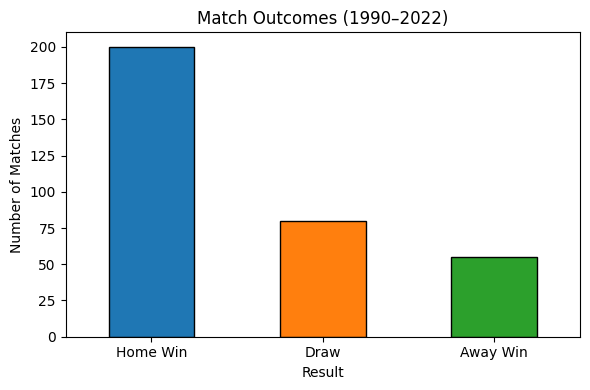

In [3]:
# Result distribution
result_counts = matches['result'].value_counts()
print(result_counts)

plt.figure(figsize=(6, 4))
result_counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
plt.title('Match Outcomes (1990–2022)')
plt.xlabel('Result')
plt.ylabel('Number of Matches')
plt.xticks(rotation=0)
plt.tight_layout()

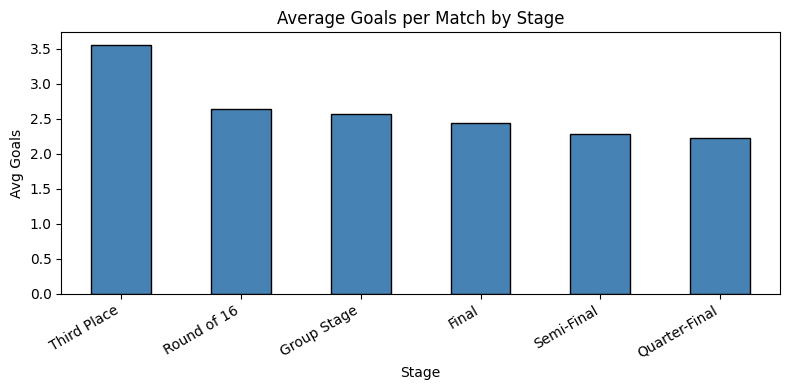

In [4]:
# Goals per stage
stage_goals = matches.groupby('stage')['total_goals'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
stage_goals.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Goals per Match by Stage')
plt.xlabel('Stage')
plt.ylabel('Avg Goals')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

## 4. Feature Engineering
We'll build simple features the model can learn from.

In [5]:
# Build a win rate lookup per team per year from team_performance
team_perf['win_rate'] = team_perf['wins'] / team_perf['matches_played']
team_perf['goal_diff_per_match'] = team_perf['goal_difference'] / team_perf['matches_played']

# Create lookup dict: (year, team) -> stats
stats = team_perf.set_index(['year', 'team'])[['win_rate', 'goal_diff_per_match', 'tournament_rank']]

def get_stat(year, team, col):
    try:
        return stats.loc[(year, team), col]
    except:
        return np.nan

# Add stats to matches
matches['home_win_rate'] = matches.apply(lambda r: get_stat(r['year'], r['home_team'], 'win_rate'), axis=1)
matches['away_win_rate'] = matches.apply(lambda r: get_stat(r['year'], r['away_team'], 'win_rate'), axis=1)
matches['home_gd_pm'] = matches.apply(lambda r: get_stat(r['year'], r['home_team'], 'goal_diff_per_match'), axis=1)
matches['away_gd_pm']= matches.apply(lambda r: get_stat(r['year'], r['away_team'],'goal_diff_per_match'), axis=1)
matches['home_rank']= matches.apply(lambda r: get_stat(r['year'], r['home_team'], 'tournament_rank'), axis=1)
matches['away_rank'] = matches.apply(lambda r: get_stat(r['year'], r['away_team'],'tournament_rank'), axis=1)

# Encode stage
le_stage = LabelEncoder()
matches['stage_enc'] = le_stage.fit_transform(matches['stage'])

print('Features added')
matches[['home_team','away_team','home_win_rate','away_win_rate','stage_enc','result']].head(10)

Features added


,home_team,away_team,home_win_rate,away_win_rate,stage_enc,result
0,Cameroon,Argentina,0.600000,0.428571,1,Home Win
1,Romania,Soviet Union,NaN,NaN,1,Home Win
2,Argentina,Soviet Union,0.428571,NaN,1,Home Win
3,Cameroon,Romania,0.600000,NaN,1,Home Win
4,Argentina,Romania,0.428571,NaN,1,Draw
5,Cameroon,Soviet Union,0.600000,NaN,1,Away Win
6,Czech Republic,USA,0.600000,NaN,1,Home Win
7,Italy,Austria,0.857143,NaN,1,Home Win
8,Italy,USA,0.857143,NaN,1,Home Win
9,Brazil,Sweden,NaN,NaN,1,Home Win


## 5. Prepare Data for Model

In [6]:
# Select features
features = ['home_win_rate', 'away_win_rate', 'home_gd_pm', 'away_gd_pm',
            'home_rank', 'away_rank', 'stage_enc', 'year']

# Drop rows with missing values
df = matches[features + ['result']].dropna()

X = df[features]
y = df['result']

In [7]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 6. Train the Model

In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print('Model trained')

Model trained


## 7. Evaluate the Model

In [9]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.2%}\n')
print(classification_report(y_test, y_pred))

Accuracy: 68.75%

              precision    recall  f1-score   support

    Away Win       1.00      0.80      0.89         5
        Draw       0.40      0.67      0.50         3
    Home Win       0.71      0.62      0.67         8

    accuracy                           0.69        16
   macro avg       0.70      0.70      0.69        16
weighted avg       0.74      0.69      0.70        16



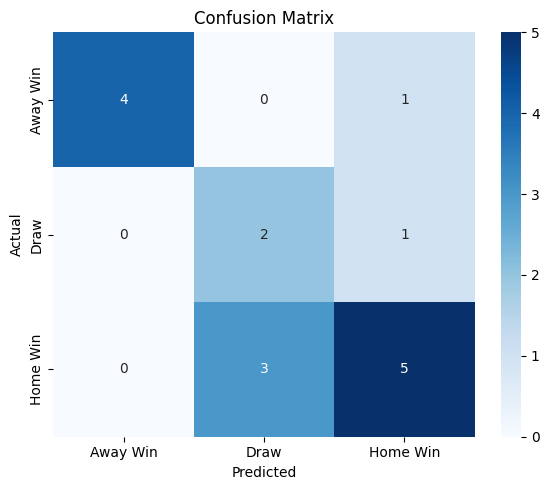

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

## 8. Feature Importance

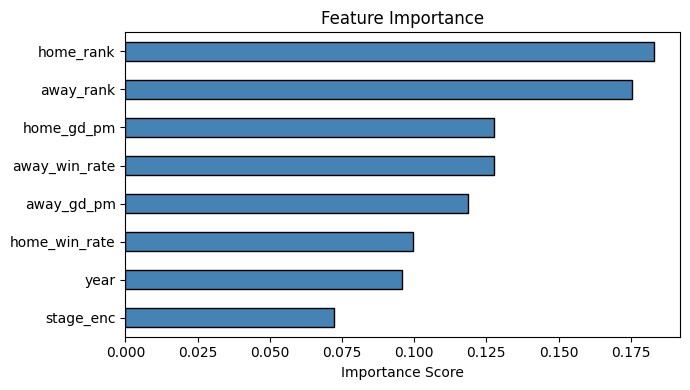

In [11]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importance.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()

## 9. Predict a Custom Match

In [12]:
# Try predicting an imaginary match

custom_match = pd.DataFrame([{
    'home_win_rate': 0.71,   # home team win rate (0 to 1)
    'away_win_rate': 0.57,   # away team win rate
    'home_gd_pm': 1.8,    # home team avg goal difference per match
    'away_gd_pm': 0.9,    # away team avg goal difference per match
    'home_rank' : 1,      # 1 = winner, 8 = lowest ranked in dataset
    'away_rank': 3,
    'stage_enc': le_stage.transform(['Final'])[0],
    'year': 2022 }])

prediction = model.predict(custom_match)[0]
probabilities = model.predict_proba(custom_match)[0]

print(f'Predicted result: {prediction}')
print()
for label, prob in zip(model.classes_, probabilities):
    print(f'  {label}: {prob:.1%}')

Predicted result: Home Win

  Away Win: 11.0%
  Draw: 33.0%
  Home Win: 56.0%


## 10. Summary

| Step | What we did |
|------|-------------|
| Data | Loaded matches + team performance CSVs |
| Features | Win rate, goal difference, stage, year, rank |
| Model | Random Forest Classifier (100 trees) |
| Output | Home Win / Away Win / Draw |

**Ideas to improve this model:**
- Add FIFA world rankings per year
- Include head-to-head history between teams
- Try XGBoost or Logistic Regression
- Add player-level features (top scorer presence, etc.)